# ELIOS Robotic Hand Calculation

Written by **Reza Fauzan Zulkarnaen**

Design by Emre Kalem (Makerworld)

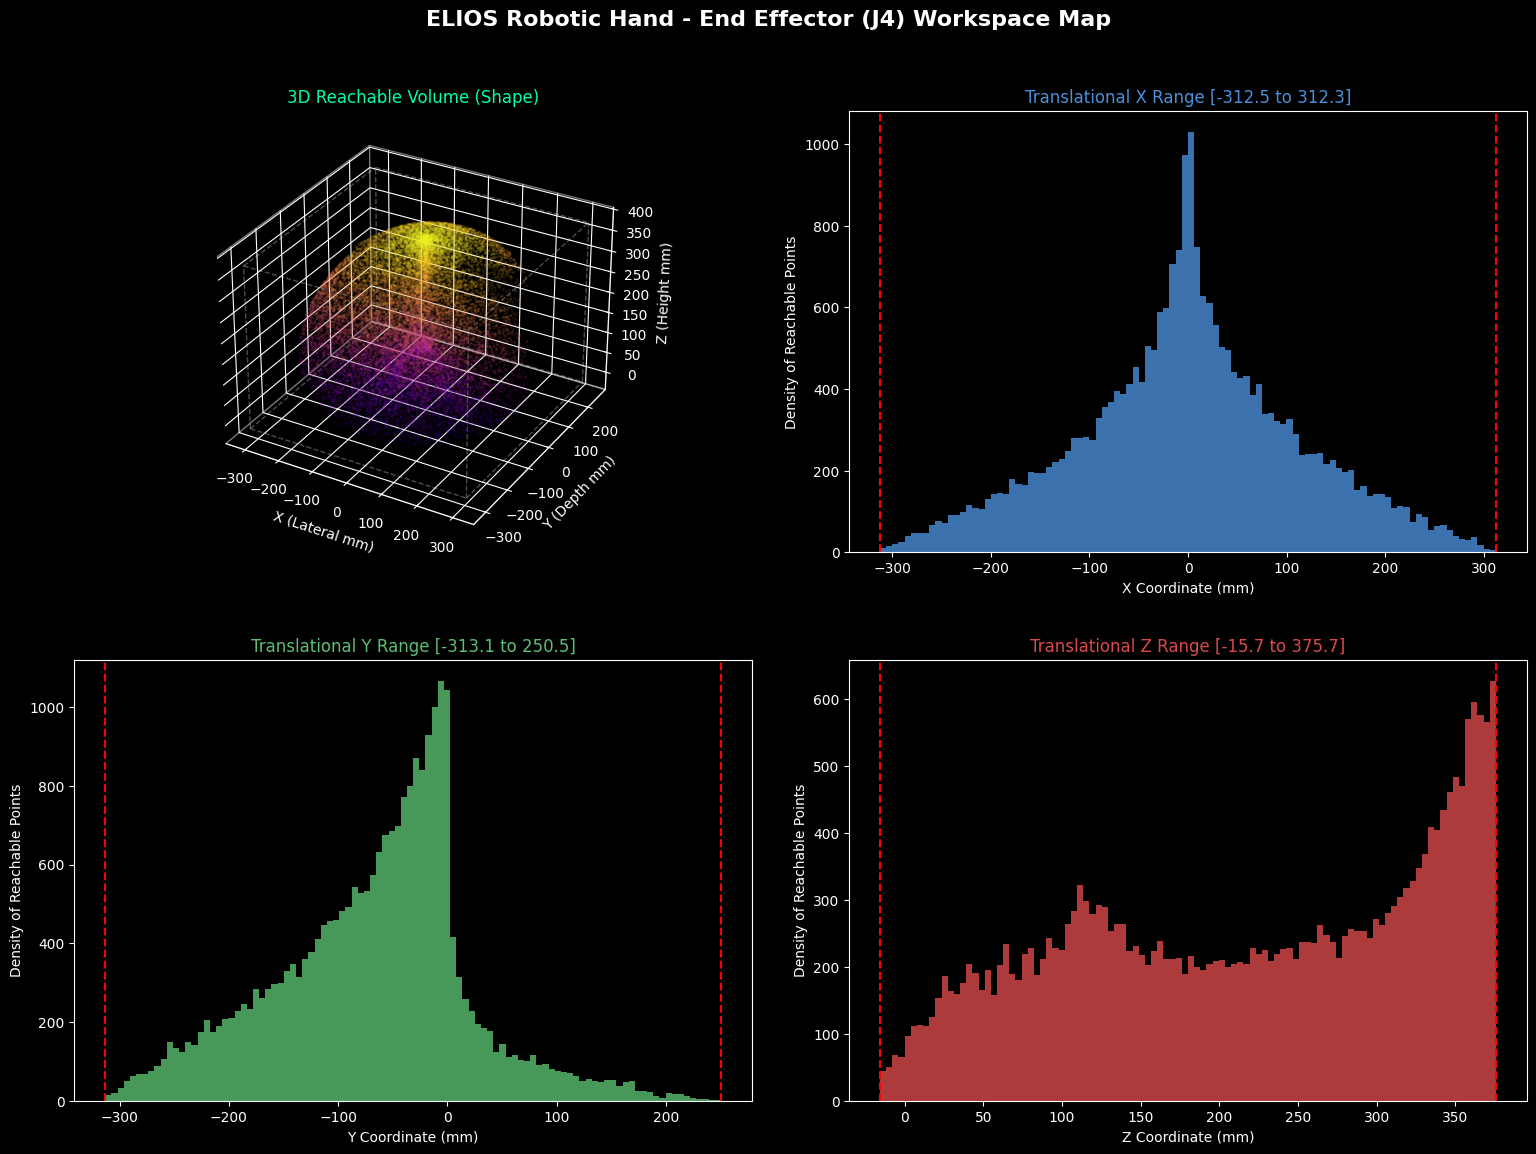

END-EFFECTOR (J4) ABSOLUTE TRANSLATIONAL LIMITS
X-Axis (Lateral) : -312.52 mm  to   312.26 mm   (Total Span: 624.78 mm)
Y-Axis (Depth)   : -313.13 mm  to   250.45 mm   (Total Span: 563.58 mm)
Z-Axis (Height)  :  -15.67 mm  to   375.70 mm   (Total Span: 391.38 mm)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# KINEMATICS CONFIGURATION (From ELIOS)
# ─────────────────────────────────────────────────────────────────────────────
# We only need J1, J2, and J3 limits because J4 and J5 do not change the 
# positional xyz coordinates of the end effector itself, only its orientation.
JOINT_LIMITS = [
    ( -90.0,  90.0),   # J1
    ( -50.0,  50.0),   # J2
    (-200.0,   0.0),   # J3
]

D_OFFSETS = [
    np.array([ 0.0,    5.0,   35.5]),   # d1: Base to J2
    np.array([ 0.0,  -47.5,  194.5]),   # d2: J2 to J3
    np.array([ 0.0,    0.0, -140.0]),   # d3: J3 to J4 (End Effector Base)
]

def Rz(theta_deg):
    t = np.radians(theta_deg)
    return np.array([[np.cos(t), -np.sin(t), 0], 
                     [np.sin(t),  np.cos(t), 0], 
                     [0,          0,         1]])

def Rx(theta_deg):
    t = np.radians(theta_deg)
    return np.array([[1, 0,          0], 
                     [0, np.cos(t), -np.sin(t)], 
                     [0, np.sin(t),  np.cos(t)]])

def compute_ee_position(j1, j2, j3):
    """Calculates End Effector (J4) XYZ position."""
    R1 = Rz(j1)
    R12 = R1 @ Rx(j2)
    R123 = R12 @ Rx(j3)

    p_J2 = R1 @ D_OFFSETS[0]
    p_J3 = p_J2 + R12 @ D_OFFSETS[1]
    p_J4 = p_J3 + R123 @ D_OFFSETS[2]
    
    return p_J4

# ─────────────────────────────────────────────────────────────────────────────
# WORKSPACE CALCULATION
# ─────────────────────────────────────────────────────────────────────────────
num_samples = 25000  # Adjust based on notebook performance vs density needs

# 1. Generate random joint angles within limits
j1_samples = np.random.uniform(JOINT_LIMITS[0][0], JOINT_LIMITS[0][1], num_samples)
j2_samples = np.random.uniform(JOINT_LIMITS[1][0], JOINT_LIMITS[1][1], num_samples)
j3_samples = np.random.uniform(JOINT_LIMITS[2][0], JOINT_LIMITS[2][1], num_samples)

# 2. Compute 3D coordinates for all samples
workspace_points = np.zeros((num_samples, 3))
for i in range(num_samples):
    workspace_points[i] = compute_ee_position(j1_samples[i], j2_samples[i], j3_samples[i])

X = workspace_points[:, 0]
Y = workspace_points[:, 1]
Z = workspace_points[:, 2]

# 3. Extract exact translational boundaries
min_x, max_x = X.min(), X.max()
min_y, max_y = Y.min(), Y.max()
min_z, max_z = Z.min(), Z.max()

# ─────────────────────────────────────────────────────────────────────────────
# PLOTTING & VISUALIZATION (Jupyter Inline)
# ─────────────────────────────────────────────────────────────────────────────
# Use a dark theme for better visual contrast similar to your previous GUI
plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 12))
fig.suptitle("ELIOS Robotic Hand - End Effector (J4) Workspace Map", fontsize=16, fontweight='bold', color='white')

# -- PLOT 1: 3D Explorable Space / Room --
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.set_title("3D Reachable Volume (Shape)", color='#00FFAA')

# Scatter the points with low alpha to see density (the 'shape')
scatter = ax1.scatter(X, Y, Z, c=Z, cmap='plasma', s=1, alpha=0.1)

# Draw a bounding box to represent the "Room" limits
for s, e in [
    ((min_x, min_y, min_z), (max_x, min_y, min_z)), ((min_x, max_y, min_z), (max_x, max_y, min_z)),
    ((min_x, min_y, max_z), (max_x, min_y, max_z)), ((min_x, max_y, max_z), (max_x, max_y, max_z)),
    ((min_x, min_y, min_z), (min_x, max_y, min_z)), ((max_x, min_y, min_z), (max_x, max_y, min_z)),
    ((min_x, min_y, max_z), (min_x, max_y, max_z)), ((max_x, min_y, max_z), (max_x, max_y, max_z)),
    ((min_x, min_y, min_z), (min_x, min_y, max_z)), ((max_x, min_y, min_z), (max_x, min_y, max_z)),
    ((min_x, max_y, min_z), (min_x, max_y, max_z)), ((max_x, max_y, min_z), (max_x, max_y, max_z))
]: ax1.plot3D(*zip(s, e), color='white', alpha=0.3, linewidth=1, linestyle='--')

ax1.set_xlabel('X (Lateral mm)')
ax1.set_ylabel('Y (Depth mm)')
ax1.set_zlabel('Z (Height mm)')
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False

# -- PLOT 2: X-Axis Range --
ax2 = fig.add_subplot(2, 2, 2)
ax2.hist(X, bins=100, color='#4A90D9', alpha=0.8)
ax2.set_title(f"Translational X Range [{min_x:.1f} to {max_x:.1f}]", color='#4A90D9')
ax2.set_xlabel('X Coordinate (mm)')
ax2.set_ylabel('Density of Reachable Points')
ax2.axvline(min_x, color='red', linestyle='--')
ax2.axvline(max_x, color='red', linestyle='--')

# -- PLOT 3: Y-Axis Range --
ax3 = fig.add_subplot(2, 2, 3)
ax3.hist(Y, bins=100, color='#5BBF72', alpha=0.8)
ax3.set_title(f"Translational Y Range [{min_y:.1f} to {max_y:.1f}]", color='#5BBF72')
ax3.set_xlabel('Y Coordinate (mm)')
ax3.set_ylabel('Density of Reachable Points')
ax3.axvline(min_y, color='red', linestyle='--')
ax3.axvline(max_y, color='red', linestyle='--')

# -- PLOT 4: Z-Axis Range --
ax4 = fig.add_subplot(2, 2, 4)
ax4.hist(Z, bins=100, color='#D94A4A', alpha=0.8)
ax4.set_title(f"Translational Z Range [{min_z:.1f} to {max_z:.1f}]", color='#D94A4A')
ax4.set_xlabel('Z Coordinate (mm)')
ax4.set_ylabel('Density of Reachable Points')
ax4.axvline(min_z, color='red', linestyle='--')
ax4.axvline(max_z, color='red', linestyle='--')

plt.tight_layout(pad=3.0)
plt.show()

# Print the numerical mapping for further feature development
print("="*50)
print("END-EFFECTOR (J4) ABSOLUTE TRANSLATIONAL LIMITS")
print("="*50)
print(f"X-Axis (Lateral) : {min_x:7.2f} mm  to  {max_x:7.2f} mm   (Total Span: {max_x - min_x:.2f} mm)")
print(f"Y-Axis (Depth)   : {min_y:7.2f} mm  to  {max_y:7.2f} mm   (Total Span: {max_y - min_y:.2f} mm)")
print(f"Z-Axis (Height)  : {min_z:7.2f} mm  to  {max_z:7.2f} mm   (Total Span: {max_z - min_z:.2f} mm)")
print("="*50)

## 2D Workspace Projections

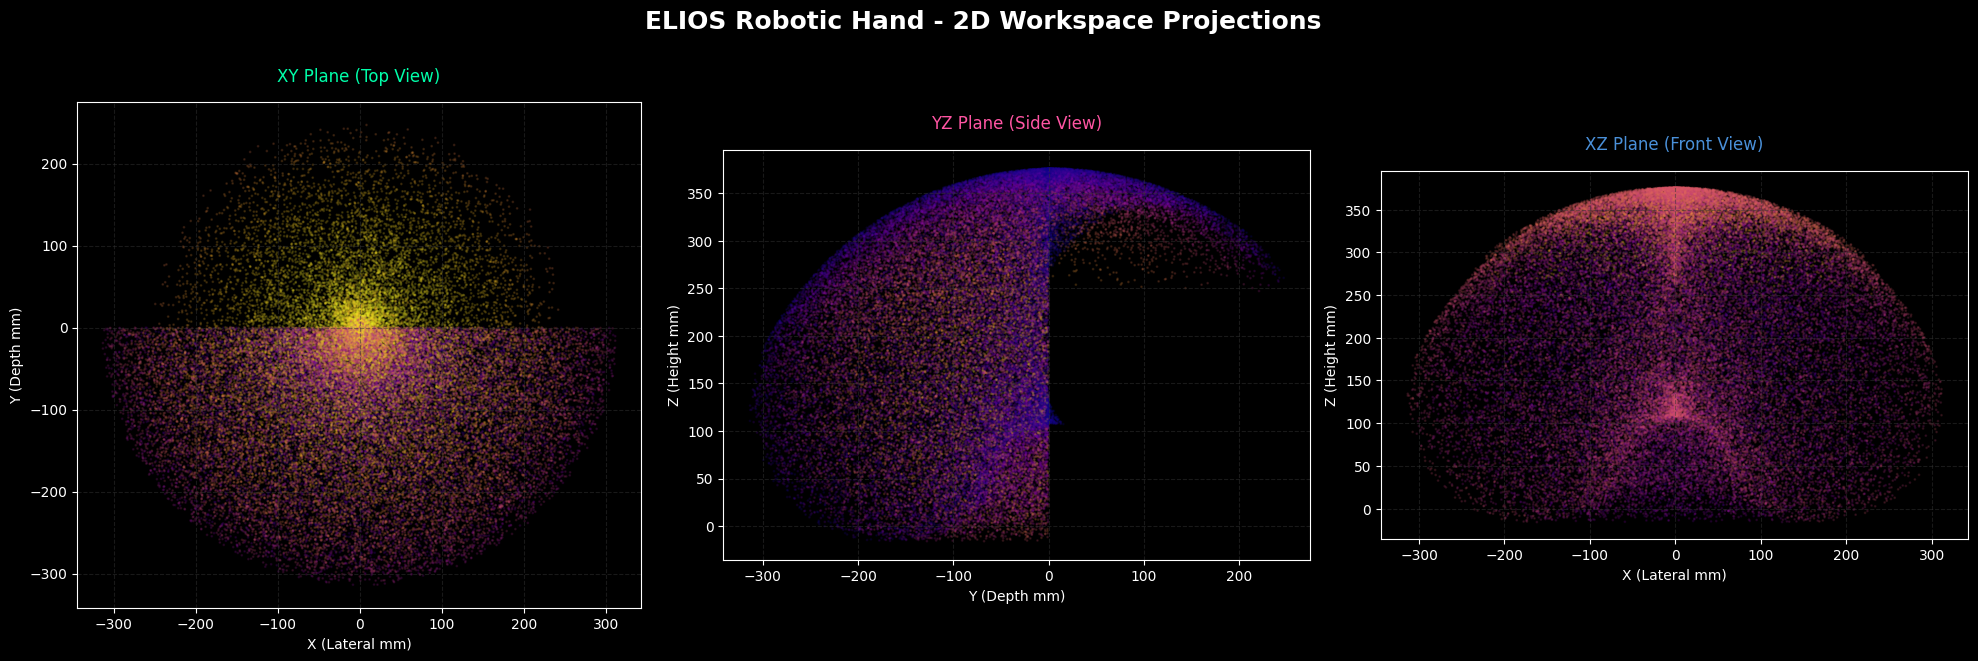

BOUNDARY BOX MAP FOR AI COLLISION/OBSERVATION SPACE
X (Lateral) : Min -313.17 mm | Max  311.64 mm
Y (Depth)   : Min -313.66 mm | Max  247.08 mm
Z (Height)  : Min  -15.80 mm | Max  375.71 mm


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# KINEMATICS CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
JOINT_LIMITS = [
    ( -90.0,  90.0),   # J1
    ( -50.0,  50.0),   # J2
    (-200.0,   0.0),   # J3
]

D_OFFSETS = [
    np.array([ 0.0,    5.0,   35.5]),   # Base to J2
    np.array([ 0.0,  -47.5,  194.5]),   # J2 to J3
    np.array([ 0.0,    0.0, -140.0]),   # J3 to J4 (End Effector Base)
]

def Rz(theta_deg):
    t = np.radians(theta_deg)
    return np.array([[np.cos(t), -np.sin(t), 0], 
                     [np.sin(t),  np.cos(t), 0], 
                     [0,          0,         1]])

def Rx(theta_deg):
    t = np.radians(theta_deg)
    return np.array([[1, 0,          0], 
                     [0, np.cos(t), -np.sin(t)], 
                     [0, np.sin(t),  np.cos(t)]])

def compute_ee_position(j1, j2, j3):
    R1 = Rz(j1)
    R12 = R1 @ Rx(j2)
    R123 = R12 @ Rx(j3)

    p_J2 = R1 @ D_OFFSETS[0]
    p_J3 = p_J2 + R12 @ D_OFFSETS[1]
    p_J4 = p_J3 + R123 @ D_OFFSETS[2]
    
    return p_J4

# ─────────────────────────────────────────────────────────────────────────────
# WORKSPACE CALCULATION
# ─────────────────────────────────────────────────────────────────────────────
num_samples = 50000  # Slightly increased for better 2D density

j1_samples = np.random.uniform(JOINT_LIMITS[0][0], JOINT_LIMITS[0][1], num_samples)
j2_samples = np.random.uniform(JOINT_LIMITS[1][0], JOINT_LIMITS[1][1], num_samples)
j3_samples = np.random.uniform(JOINT_LIMITS[2][0], JOINT_LIMITS[2][1], num_samples)

workspace_points = np.zeros((num_samples, 3))
for i in range(num_samples):
    workspace_points[i] = compute_ee_position(j1_samples[i], j2_samples[i], j3_samples[i])

X = workspace_points[:, 0]
Y = workspace_points[:, 1]
Z = workspace_points[:, 2]

# ─────────────────────────────────────────────────────────────────────────────
# 2D PROJECTION PLOTTING (Jupyter Inline)
# ─────────────────────────────────────────────────────────────────────────────
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("ELIOS Robotic Hand - 2D Workspace Projections", fontsize=18, fontweight='bold', color='white', y=1.05)

# -- PLOT 1: XY Plane (Top-Down View) --
# Coloring points by Z height to add depth information
axes[0].scatter(X, Y, c=Z, cmap='plasma', s=1, alpha=0.15)
axes[0].set_title("XY Plane (Top View)", color='#00FFAA', pad=15)
axes[0].set_xlabel('X (Lateral mm)')
axes[0].set_ylabel('Y (Depth mm)')
axes[0].set_aspect('equal')  # Prevents distortion
axes[0].grid(True, color='#333333', linestyle='--', alpha=0.5)

# -- PLOT 2: YZ Plane (Side View) --
# Coloring points by X lateral position
axes[1].scatter(Y, Z, c=np.abs(X), cmap='plasma', s=1, alpha=0.15)
axes[1].set_title("YZ Plane (Side View)", color='#FF55A3', pad=15)
axes[1].set_xlabel('Y (Depth mm)')
axes[1].set_ylabel('Z (Height mm)')
axes[1].set_aspect('equal')
axes[1].grid(True, color='#333333', linestyle='--', alpha=0.5)

# -- PLOT 3: XZ Plane (Front View) --
# Coloring points by Y depth position
axes[2].scatter(X, Z, c=Y, cmap='plasma', s=1, alpha=0.15)
axes[2].set_title("XZ Plane (Front View)", color='#4A90D9', pad=15)
axes[2].set_xlabel('X (Lateral mm)')
axes[2].set_ylabel('Z (Height mm)')
axes[2].set_aspect('equal')
axes[2].grid(True, color='#333333', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print limits mapping
print("="*60)
print("BOUNDARY BOX MAP FOR AI COLLISION/OBSERVATION SPACE")
print("="*60)
print(f"X (Lateral) : Min {X.min():7.2f} mm | Max {X.max():7.2f} mm")
print(f"Y (Depth)   : Min {Y.min():7.2f} mm | Max {Y.max():7.2f} mm")
print(f"Z (Height)  : Min {Z.min():7.2f} mm | Max {Z.max():7.2f} mm")
print("="*60)

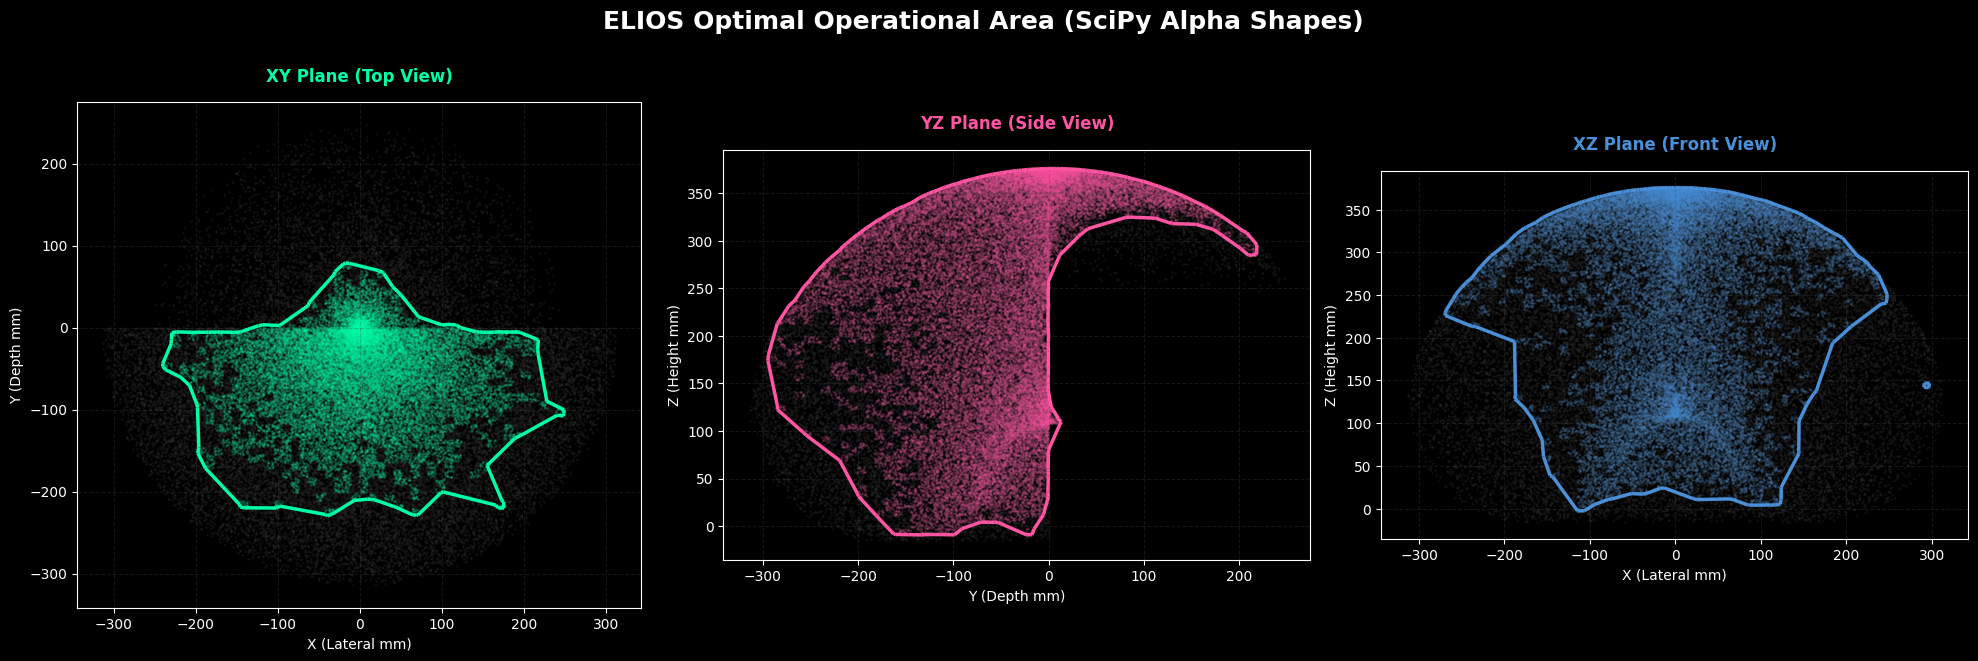

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from matplotlib.collections import LineCollection

# (Assume workspace_points is already calculated from the previous step)

# ─────────────────────────────────────────────────────────────────────────────
# 3. SCIPY DELAUNAY ALPHA SHAPE LOGIC
# ─────────────────────────────────────────────────────────────────────────────
def get_scipy_alpha_shape(pts_2d, density_threshold=0.03, alpha_radius=80.0):
    """
    1. Filters sparse points using a 2D histogram.
    2. Computes the Alpha Shape (Concave Hull) using SciPy Delaunay Triangulation.
       - alpha_radius (mm): Maximum allowed radius for a boundary triangle. 
         Lower = tighter shrink-wrap. Higher = closer to Convex Hull.
    """
    # -- Step A: Density Filtering --
    H, xedges, yedges = np.histogram2d(pts_2d[:,0], pts_2d[:,1], bins=60)
    
    x_idx = np.clip(np.digitize(pts_2d[:,0], xedges) - 1, 0, H.shape[0]-1)
    y_idx = np.clip(np.digitize(pts_2d[:,1], yedges) - 1, 0, H.shape[1]-1)
    point_densities = H[x_idx, y_idx]
    
    dense_mask = point_densities > (H.max() * density_threshold)
    dense_points = pts_2d[dense_mask]
    
    # -- Step B: Delaunay Triangulation --
    tri = Delaunay(dense_points)
    boundary_edges = set()
    
    # Loop through all generated triangles
    for ia, ib, ic in tri.simplices:
        pa, pb, pc = dense_points[ia], dense_points[ib], dense_points[ic]
        
        # Calculate side lengths of the triangle
        a = np.linalg.norm(pa - pb)
        b = np.linalg.norm(pb - pc)
        c = np.linalg.norm(pc - pa)
        
        # Calculate Area (Heron's formula) and Circumradius
        s = (a + b + c) / 2.0
        area = np.sqrt(max(s * (s - a) * (s - b) * (s - c), 0))
        
        circum_r = (a * b * c) / (4.0 * area) if area > 0 else np.inf
        
        # If the triangle is small enough, it belongs to the dense shape
        if circum_r < alpha_radius:
            # Check all 3 edges of the triangle
            for edge in [(ia, ib), (ib, ic), (ic, ia)]:
                edge = tuple(sorted(edge))
                # If an edge is shared by two triangles, it's internal (remove it)
                # If an edge only appears once, it's an outer boundary (keep it)
                if edge in boundary_edges:
                    boundary_edges.remove(edge)
                else:
                    boundary_edges.add(edge)
                    
    return dense_points, list(boundary_edges)

# ─────────────────────────────────────────────────────────────────────────────
# 4. PROCESS & PLOT
# ─────────────────────────────────────────────────────────────────────────────
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("ELIOS Optimal Operational Area (SciPy Alpha Shapes)", 
             fontsize=18, fontweight='bold', color='white', y=1.05)

planes = [
    ("XY Plane (Top View)", 0, 1, 'X (Lateral mm)', 'Y (Depth mm)', '#00FFAA'),
    ("YZ Plane (Side View)", 1, 2, 'Y (Depth mm)', 'Z (Height mm)', '#FF55A3'),
    ("XZ Plane (Front View)", 0, 2, 'X (Lateral mm)', 'Z (Height mm)', '#4A90D9')
]

for idx, (title, i, j, xlabel, ylabel, color) in enumerate(planes):
    ax = axes[idx]
    pts_2d = workspace_points[:, [i, j]]
    
    # Calculate the optimal core points and the boundary edges
    # alpha_radius=40.0 mm acts as our mathematical shrink-wrap tightness
    dense_points, boundary_edges = get_scipy_alpha_shape(pts_2d, density_threshold=0.03, alpha_radius=40.0)
    
    # 1. Plot all raw points in faint grey (Sparse Reach)
    ax.scatter(pts_2d[:, 0], pts_2d[:, 1], c='#333333', s=1, alpha=0.2, label='Sparse Reach')
    
    # 2. Plot the dense points in faint color (Optimal Reach)
    ax.scatter(dense_points[:, 0], dense_points[:, 1], c=color, s=1, alpha=0.1)
    
    # 3. Draw the SciPy Alpha Shape Boundary using a LineCollection for fast rendering
    lines = [[dense_points[edge[0]], dense_points[edge[1]]] for edge in boundary_edges]
    lc = LineCollection(lines, colors=color, linewidths=2.5, linestyle='-')
    ax.add_collection(lc)
    
    ax.set_title(title, color=color, pad=15, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect('equal')
    ax.grid(True, color='#444444', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()